(python_by_example)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# An Introductory Example

```{index} single: Python; Introductory Example
```

## Overview

ഇനി നമുക്ക് Python language-നെ പറ്റി പഠിക്കാം.

ഈ lecture-ൽ, നമ്മൾ ചെറിയ Python programs എഴുതി, അവയെ വിശദമായി പരിശോധിക്കും.

Basic Python syntax-ഉം data structures-ഉം നിങ്ങൾക്ക് introduce ചെയ്തു തരിക എന്നതാണ് ഈ lecture-ന്റെ ലക്ഷ്യം.

കൂടുതൽ ആഴത്തിലുള്ള concepts പിന്നീടുള്ള lectures-ൽ cover ചെയ്യും.

ഈ lecture-ലേക്കു കടക്കുന്നതിനു മുമ്പ് നിങ്ങൾ getting started with Python എന്ന {doc}`lecture <getting_started>` വായിച്ചിട്ടുണ്ടാകും എന്ന് കരുതുന്നു.


## The Task: Plotting a White Noise Process

നമുക്ക് ഒരു white noise process ($\epsilon_0, \epsilon_1, \ldots, \epsilon_T$) simulate ചെയ്ത്, plot ചെയ്യണം എന്ന് കരുതുക — ഓരോ draw-ഉം ($\epsilon_t$) ഒരു independent standard normal ആണ്.

അതായത്, താഴെ കൊടുത്തിരിക്കുന്നത് പോലെയുള്ള ഒരു figure നമുക്ക് generate ചെയ്യണം:

```{figure} /_static/lecture_specific/python_by_example/test_program_1_updated.png
:scale: 120
```

(ഇവിടെ $t$ horizontal axis-ലും, $\epsilon_t$ vertical axis-ലും ആണ്.)

ഈ white noise process plotting നമ്മൾ പല വിധത്തിൽ ചെയ്യും — ഓരോ രീതിയിൽ ചെയ്യുമ്പോഴും നമ്മൾ Python-നെക്കുറിച്ച് കൂടുതൽ കാര്യങ്ങൾ പഠിക്കും.

## Version 1

(ourfirstprog)=
നമ്മൾ set ചെയ്ത task ചെയ്യുന്ന കുറച്ച് lines of code താഴെ കാണാം.

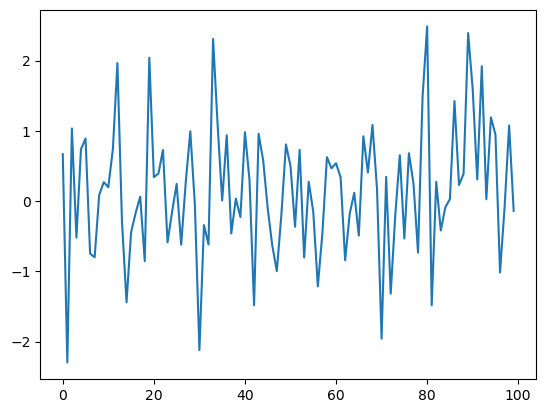

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
ϵ_values = rng.standard_normal(100)
plt.plot(ϵ_values)
plt.show()

നമുക്ക് ഈ program-നെ break down ചെയ്ത്, അത് എങ്ങനെ work ചെയ്യുന്നു എന്ന് നോക്കാം.

(import)=
### Imports

ഈ program-ന്റെ ആദ്യത്തെ രണ്ട് lines, external code libraries-ൽ നിന്നും functionality import ചെയ്യുന്നു.

ആദ്യത്തെ line {doc}`NumPy <numpy>` import ചെയ്യുന്നു — NumPy, താഴെ കൊടുത്തിരിക്കുന്ന പോലത്തെ tasks-കൾ ചെയ്യാനുള്ള ഒരു Python package ആണ്:

* working with arrays (vectors and matrices)
* common mathematical functions like `cos` and `sqrt`
* generating random numbers
* linear algebra, etc.

`import numpy as np` ചെയ്ത് കഴിഞ്ഞാൽ, `np.attribute` എന്ന syntax ഉപയോഗിച്ച് ഈ attributes നമുക്ക് access ചെയ്യാം.

Here's two more examples

In [2]:
np.sqrt(4)

np.float64(2.0)

In [3]:
np.log(4)

np.float64(1.3862943611198906)

#### Why So Many Imports?

Python programs-ൽ സാധാരണയായി multiple import statements ആവശ്യമായിവരുന്നു.

കാരണം, core language മനഃപൂർവ്വം ചെറുതായി നിലനിർത്തിയിരിക്കുന്നു, അതുകൊണ്ട് അത് പഠിക്കാനും maintain ചെയ്യാനും improve ചെയ്യാനും easy ആണ്.

Python ഉപയോഗിച്ച് interesting ആയ എന്തെങ്കിലും ചെയ്യണമെങ്കിൽ, മിക്ക സമയത്തും additional functionality import ചെയ്യേണ്ടി വരും.


#### Packages

```{index} single: Python; Packages
```

മുകളിൽ പറഞ്ഞതുപോലെ, NumPy ഒരു Python package ആണ്.

Share ചെയ്യാൻ ആഗ്രഹിക്കുന്ന code-നെ organize ചെയ്യാനാണ് developers packages ഉപയോഗിക്കുന്നത്.

In fact, ഒരു **package** എന്നത് താഴെ കൊടുത്തിരിക്കുന്നവ അടങ്ങിയ ഒരു directory ആണ്:

1. Python code ഉള്ള files — Python-ന്റെ ഭാഷയിൽ ഇവയെ **modules** എന്ന് വിളിക്കുന്നു
1. Python-ന് access ചെയ്യാൻ കഴിയുന്ന compiled code (e.g., functions compiled from C or FORTRAN code)
1. `__init__.py` എന്ന ഒരു file — നമ്മൾ `import package_name` type ചെയ്യുമ്പോൾ എന്ത് execute ചെയ്യണം എന്ന് ഇത് specify ചെയ്യുന്നു

NumPy-യുടെ `__init__.py`-യുടെ location check ചെയ്യാൻ, താഴെ കൊടുത്തിരിക്കുന്ന code Python-ൽ run ചെയ്യുക:

```{code-block} ipython
:class: no-execute

import numpy as np

print(np.__file__)
```

#### Subpackages

```{index} single: Python; Subpackages
```

`rng = np.random.default_rng()` എന്ന line നോക്കുക.

ഇവിടെ `np` എന്നത് NumPy package-നെ refer ചെയ്യുന്നു, അതേ സമയം `random` എന്നത് NumPy-യുടെ ഒരു **subpackage** ആണ്.

Subpackages എന്നത് മറ്റൊരു package-ന്റെ subdirectory ആയ packages മാത്രമാണ്.

ഉദാഹരണത്തിന്, NumPy-യുടെ directory-യിൽ `random` എന്ന folder കാണാം.

### Importing Names Directly

മുകളിൽ കണ്ട ഈ code ഓർക്കുക

In [4]:
import numpy as np

np.sqrt(4)

np.float64(2.0)

NumPy-യുടെ square root function access ചെയ്യാനുള്ള മറ്റൊരു രീതി താഴെ കാണാം:

In [5]:
from numpy import sqrt

sqrt(4)

np.float64(2.0)

ഇതും correct ആണ്.

ഇതിന്റെ advantage — നമ്മുടെ code-ൽ `sqrt` പലപ്പോഴും ഉപയോഗിക്കുകയാണെങ്കിൽ, ഇതുവഴി നമുക്ക് typing കുറക്കാൻ സാധിക്കും.

ഇതിന്റെ disadvantage — ഒരു long program-ൽ, ഈ രണ്ട് lines-ന്റെയും ഇടയിൽ മറ്റ് പല lines-ഉം വന്നേക്കാം.

അങ്ങനെ വരുമ്പോൾ, `sqrt` എവിടെ നിന്ന് വന്നു എന്ന് readers-ന് മനസ്സിലാക്കാൻ ബുദ്ധിമുട്ടായേക്കാം.

### Random Draws

White noise plot ചെയ്യുന്ന നമ്മുടെ program-ലേക്ക് തിരികെ വരാം. Import statements കഴിഞ്ഞുള്ള ബാക്കി മൂന്ന് lines ഇവയാണ്:

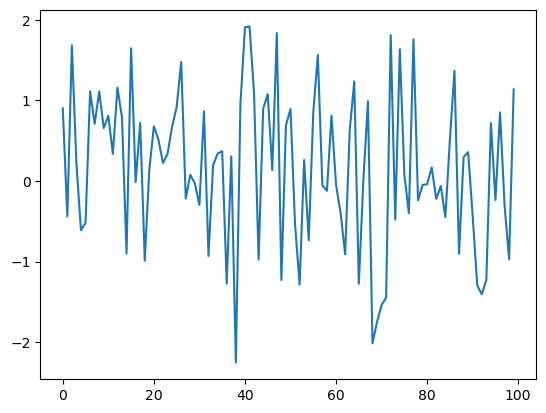

In [6]:
ϵ_values = rng.standard_normal(100)
plt.plot(ϵ_values)
plt.show()

ആദ്യത്തെ line, 100 (quasi) independent standard normals-നെ generate ചെയ്ത്, `ϵ_values`-ൽ store ചെയ്യുന്നു.

അടുത്ത രണ്ട് lines plot generate ചെയ്യുന്നു.

ഈ plot configure ചെയ്യാനും improve ചെയ്യാനുമുള്ള പല വഴികൾ നമുക്ക് താഴെ കാണാം.

## Alternative Implementations

Standard normal distribution-ൽ നിന്നും IID draws plot ചെയ്ത {ref}`നമ്മുടെ ആദ്യത്തെ program <ourfirstprog>`, മറ്റു പല രീതികളിൽ എങ്ങനെ എഴുതാം എന്ന് നോക്കാം.

താഴെ കൊടുത്തിരിക്കുന്ന programs, original-ന്റെ അത്ര efficient അല്ല - അവ ഒരു ആശയം വിശദീകരിക്കാനായി മാത്രം നിർമ്മിച്ചവയാണ്.

എന്നാൽ ഇവ ഒരു familiar setting-ൽ ചില പ്രധാന Python syntax-ഉം, semantics-ഉം illustrate ചെയ്യാൻ സഹായിക്കുന്നു.

### A Version with a For Loop

`for` loops-ഉം, Python lists-ഉം illustrate ചെയ്യുന്ന ഒരു version താഴെ കാണാം:

(firstloopprog)=

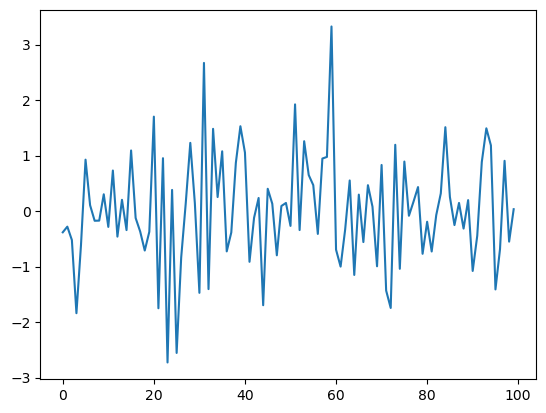

In [7]:
ts_length = 100
ϵ_values = []   # empty list

for i in range(ts_length):
    e = rng.standard_normal()
    ϵ_values.append(e)

plt.plot(ϵ_values)
plt.show()

ചുരുക്കത്തിൽ,

* ആദ്യത്തെ line, time series-ന് ആവശ്യമായ length set ചെയ്യുന്നു.
* അടുത്ത line, `ϵ_values` എന്നൊരു empty *list* create ചെയ്യുന്നു — അതിൽ ആയിരിക്കും നമ്മൾ generate ചെയ്യുന്ന $\epsilon_t$ values store ചെയ്യുക.
* `# empty list` എന്ന statement ഒരു *comment* ആണ്, Python-ന്റെ interpreter ഇത് ignore ചെയ്യും.
* അടുത്ത മൂന്ന് lines ആണ് `for` loop — ഇത് repeatedly ഒരു പുതിയ random number $\epsilon_t$ draw ചെയ്ത് `ϵ_values` list-ന്റെ അവസാനം append ചെയ്യുന്നു.
* അവസാനത്തെ രണ്ട് lines, plot generate ചെയ്ത്, user-ന് display ചെയ്യുന്നു.

ഈ program-ന്റെ കുറച്ചു ഭാഗങ്ങൾ നമുക്ക് വിശദമായി പഠിക്കാം.

(lists_ref)=
### Lists

```{index} single: Python; Lists
```

`ϵ_values = []` എന്ന statement നോക്കുക. ഇത് ഒരു empty list create ചെയ്യുന്നു.

ഒരു കൂട്ടം objects-നെ ഒരുമിച്ച് group ചെയ്യാൻ ഉപയോഗിക്കുന്ന Python-ന്റെ ഒരു native data structure ആണ് Lists.

Lists-ലെ items ordered ആണ്, കൂടാതെ lists-ൽ duplicates അനുവദനീയമാണ്.

ഉദാഹരണത്തിന്, ഇത് try ചെയ്യുക

In [8]:
x = [10, 'foo', False]
type(x)

list

`x`-ന്റെ ആദ്യത്തെ element ഒരു [integer](https://en.wikipedia.org/wiki/Integer_(computer_science)) ആണ്, അടുത്തത് ഒരു [string](https://en.wikipedia.org/wiki/String_(computer_science)) ആണ്, മൂന്നാമത്തേത് ഒരു [Boolean value](https://en.wikipedia.org/wiki/Boolean_data_type) ആണ്.

ഒരു list-ലേക്ക് ഒരു value add ചെയ്യാൻ, `list_name.append(some_value)` എന്ന syntax നമുക്ക് ഉപയോഗിക്കാം

In [9]:
x

[10, 'foo', False]

In [10]:
x.append(2.5)
x

[10, 'foo', False, 2.5]

ഇവിടെ `append()` എന്നത് ഒരു **method** ആണ്. ഒരു object-നോട് "attach" ആയിരിക്കുന്ന ഒരു function-നെയാണ് method എന്ന് വിളിക്കുന്നത്. ഇവിടെ ആ object `x` എന്ന list ആണ്.

Methods-നെ പറ്റി നമ്മൾ {doc}`പിന്നീട് <oop_intro>` വിശദമായി പഠിക്കും, പക്ഷേ ഇപ്പോൾ ഒരു idea കിട്ടാൻ നിങ്ങൾ ഇത്രെയും മനസിലാക്കുക:

* Lists, strings തുടങ്ങിയ Python objects-ന് എല്ലാം, അവയിൽ അടങ്ങിയിരിക്കുന്ന data manipulate ചെയ്യാൻ ഉപയോഗിക്കുന്ന methods ഉണ്ട്.
* String objects-ന് [string methods](https://docs.python.org/3/library/stdtypes.html#string-methods) ഉണ്ട്, list objects-ന് [list methods](https://docs.python.org/3/tutorial/datastructures.html#more-on-lists) ഉണ്ട്, അങ്ങനെ ഓരോ object-ഇനും അതിന് suitable ആയ methods ഉണ്ടായിരിക്കും.

മറ്റൊരു useful list method ആണ് `pop()`

In [11]:
x

[10, 'foo', False, 2.5]

In [12]:
x.pop()

2.5

In [13]:
x

[10, 'foo', False]

Python-ലെ lists zero-based ആണ് (as in C, Java or Go). അതിനാൽ list-ൽ, ആദ്യത്തെ element-ന്റെ reference `x[0]` ആയി ഉപയോഗിക്കുന്നു

In [14]:
x[0]   # first element of x

10

In [15]:
x[1]   # second element of x

'foo'

### The For Loop

```{index} single: Python; For loop
```

ഇനി നമുക്ക് {ref}`മുകളിലുള്ള program <firstloopprog>`-ലെ `for` loop നോക്കാം. അവിടെ നമ്മൾ ഉപയോഗിച്ച `for` loop താഴെ കാണാം:

In [16]:
for i in range(ts_length):
    e = rng.standard_normal()
    ϵ_values.append(e)

Indent ചെയ്തിരിക്കുന്ന ഈ രണ്ട് lines, `ts_length` തവണ execute ചെയ്ത ശേഷമേ Python മുന്നോട്ട് പോകൂ.

ഈ രണ്ട് lines-നെ നാം **code block** എന്ന് വിളിക്കുന്നു - കാരണം നമ്മൾ `for` loop ഉപയോഗിച്ച് ഈ "block" of code-നെയാണ് loop ചെയ്യിക്കുന്നത്.

ഒരു code block എവിടെ വരെ extent ചെയ്യുന്നു എന്ന് Python മനസ്സിലാക്കുന്നത് അതിന്റെ *indentation മാത്രം* ഉപയോഗിച്ചാണ്. ഇത്, മറ്റു പല programming languages-ൽ നിന്നും Python-നെ വ്യത്യസ്തമാക്കുന്നു.

നമ്മുടെ program-ൽ, `ϵ_values.append(e)` എന്ന line-ന് ശേഷം indentation കുറയുന്നു. ഇതിലൂടെ, ആ code block അവിടെ അവസാനിക്കുന്നു എന്ന് Python മനസ്സിലാക്കുന്നു.

Indentation-നെ പറ്റി കൂടുതൽ താഴെ കാണാം — ഇപ്പോൾ `for` loop-ന്റെ മറ്റൊരു example നോക്കാം.

In [17]:
animals = ['dog', 'cat', 'bird']
for animal in animals:
    print("The plural of " + animal + " is " + animal + "s")

The plural of dog is dogs
The plural of cat is cats
The plural of bird is birds


ഈ example, `for` loop എങ്ങനെ പ്രവർത്തിക്കുന്നു എന്ന് clarify ചെയ്യാൻ സഹായിക്കുന്നു: താഴെ കൊടുത്തിരിക്കുന്ന രീതിയിൽ ഒരു loop execute ചെയ്യുമ്പോൾ,

```{code-block} python3
:class: no-execute

for variable_name in sequence:
    <code block>
```

Python interpreter ഇവ perform ചെയ്യുന്നു:

* `sequence`-ലെ ഓരോ element-ഇനും, Python ആ element-നെ `variable_name` എന്ന name "bind" ചെയ്യുന്നു. തുടർന്ന് code block execute ചെയ്യുന്നു.


### A Comment on Indentation

```{index} single: Python; Indentation
```

`for` loop discuss ചെയ്തപ്പോൾ, loop ചെയ്യപ്പെടുന്ന code block-ന്റെ delimit, അതിന്റെ indentation ഉപയോഗിച്ചാണ് Python മനസ്സിലാക്കുന്നതെന്ന് നമ്മൾ discuss ചെയ്തിരുന്നു.

In fact, Python-ൽ, *എല്ലാ* code blocks-ഉം (അതായത്, loops-ന്റെ code block, if clauses-ന്റെ code block, function definitions-ന്റെ code block, etc.) indentation ഉപയോഗിച്ചാണ് delimit ചെയ്യപ്പെടുന്നത്.

അതിനാൽ, മറ്റു മിക്ക programming languages-ൽ നിന്നും വ്യത്യസ്തമായി, Python code-ലെ whitespace, program-ന്റെ output-നെ affect ചെയ്യുന്നു.

ഒരിക്കൽ ഇത് ശീലമായാൽ, ഇത് ഒരു നല്ല കാര്യമാണ്.

* clean-ഉം consistent-ഉം ആയ indentation വഴി readability improve ചെയ്യുന്നു
* മറ്റ് languages-ൽ ഉപയോഗിക്കുന്ന brackets അല്ലെങ്കിൽ end statements പോലുള്ള clutter remove ചെയ്യുന്നു

On the other hand, ഇത് correct ആയി ഉപയോഗിക്കാൻ ഒരല്പം care ആവശ്യമാണ്. അതിനാൽ താഴെപ്പറയുന്ന കാര്യങ്ങൾ ഓർത്തിരിക്കുക:

* ഒരു code block ആരംഭിക്കുന്നതിന് മുമ്പുള്ള line എപ്പോഴും colon-ൽ അവസാനിക്കണം
    * `for i in range(10):`
    * `if x > y:`
    * `while x < 100:`
    * etc. 
* ഒരു code block-ലെ എല്ലാ lines-ഇനും ഒരേ amount of indentation ഉണ്ടായിരിക്കണം.
* Python-ന്റെ standard 4 spaces ആണ്. അതിനാൽ നിങ്ങളും 4 spaces ഉപയോഗിക്കണം.

### While Loops

```{index} single: Python; While loop
```

Python-ൽ iteration ചെയ്യാൻ ഏറ്റവും common ആയി ഉപയോഗിക്കുന്ന technique ആണ് `for` loop.

എന്നാൽ, illustration purpose-ന് വേണ്ടി, {ref}`മുൻപത്തെ program-ൽ <firstloopprog>` `for` loop-നു പകരം `while` loop ഉപയോഗിച്ച് എങ്ങനെ ചെയ്യാം എന്ന് നോക്കാം.

(whileloopprog)=

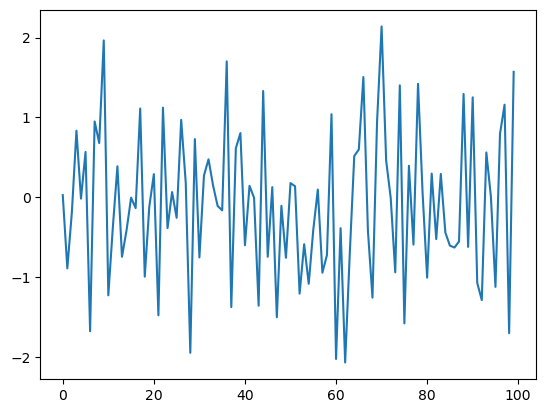

In [18]:
ts_length = 100
ϵ_values = []
i = 0
while i < ts_length:
    e = rng.standard_normal()
    ϵ_values.append(e)
    i = i + 1
plt.plot(ϵ_values)
plt.show()

Indentation ഉപയോഗിച്ച് delimit ചെയ്തിരിക്കുന്ന while loop-ന്റെ code block, (```i < ts_length```) എന്ന condition satisfy ആകുന്നത് വരെ execute ചെയ്ത് കൊണ്ടേയിരിക്കും.

ഈ case-ൽ, ```i``` ```ts_length```-ന് equal ആകുന്നത് വരെ program ```ϵ_values``` list-ലേക്ക് values add ചെയ്ത് കൊണ്ടേയിരിക്കും:

In [19]:
i == ts_length #the ending condition for the while loop

True

ശ്രദ്ധിക്കുക,

* `while` loop-ന്റെ code block, indentation മാത്രം ഉപയോഗിച്ചാണ് delimit ചെയ്തിരിക്കുന്നത്.
* `i = i + 1` എന്ന statement-ന് പകരം `i += 1` എന്നും എഴുതാം.

## Another Application

Exercises-ലേക്ക് കടക്കുന്നതിന് മുമ്പ് ഒരു application കൂടി നോക്കാം.

ഈ application-ൽ, സമയം കടന്നുപോകുന്നതിനനുസരിച്ച് ഒരു bank account-ന്റെ balance എങ്ങനെ മാറുന്നു എന്ന് നാം plot ചെയ്യുന്നു.

ഈ application-നു വേണ്ടി നമ്മൾ consider ചെയ്യുന്ന time period-ൽ withdraws ഒന്നുമില്ല. കൂടാതെ, നമ്മുടെ time period-ന്റെ last date $T$ എന്ന് denote ചെയ്യുന്നു.

Initial balance $b_0$ ആണ്, interest rate $r$ ആണ്.

സമയം $t$-ൽ നിന്നും $t+1$ ആകുമ്പോൾ, balance update ചെയ്യേണ്ട formula: $b_{t+1} = (1 + r) b_t$

താഴെയുള്ള code-ൽ, $b_0, b_1, \ldots, b_T$ എന്ന sequence നാം generate ചെയ്ത് plot ചെയ്യുന്നു.

ഈ sequence store ചെയ്യാൻ ഒരു Python list ഉപയോഗിക്കുന്നതിന് പകരം, നമ്മൾ ഒരു NumPy
array ഉപയോഗിക്കും.

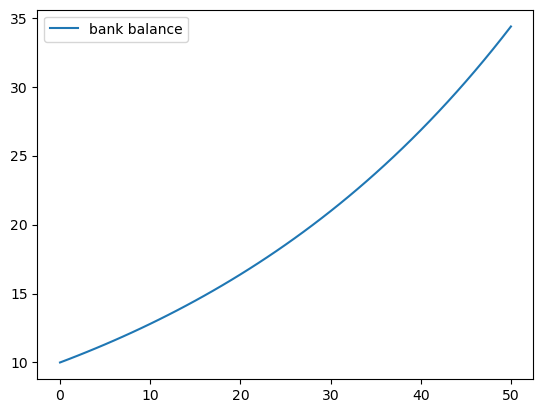

In [20]:
r = 0.025         # interest rate
T = 50            # end date
b = np.empty(T+1) # an empty NumPy array, to store all b_t
b[0] = 10         # initial balance

for t in range(T):
    b[t+1] = (1 + r) * b[t]

plt.plot(b, label='bank balance')
plt.legend()
plt.show()

`b = np.empty(T+1)` എന്ന statement, `T+1` (floating point) numbers-നുള്ള storage space, memory-യിൽ allocate ചെയ്യുന്നു.

ഈ numbers `for` loop വഴി fill ചെയ്യപ്പെടുന്നു.

തുടക്കത്തിൽ തന്നെ memory allocate ചെയ്യുന്നത്, Python list-ഉം `append`-ഉം ഉപയോഗിക്കുന്നതിനേക്കാൾ efficient ആണ് — കാരണം, രണ്ടാമത്തെ രീതിയിൽ (list, append), ഓരോ തവണയും storage space നൽകണമെന്ന് operating system-നോട് ആവശ്യപ്പെടേണ്ടി വരും.

Plot-ൽ നമ്മൾ ഒരു legend add ചെയ്തത് ശ്രദ്ധിക്കുക — exercises-ൽ നിങ്ങളോട് ഇത് ഉപയോഗിക്കാൻ ആവശ്യപ്പെടും.

## Exercises

ഇനി നമ്മൾ exercises-ലേക്ക് കടക്കുന്നു. ഇവ complete ചെയ്തതിന് ശേഷം മാത്രം മുന്നോട്ട് പോകുക — കാരണം, ഇവിടെ പരിചയപ്പെടുത്തുന്ന concepts നമുക്ക് പിന്നീട് ആവശ്യമായി വരും.

```{exercise-start}
:label: pbe_ex1
```

നിങ്ങളുടെ ആദ്യത്തെ task, correlated ആയ ഈ time series-നെ simulate ചെയ്ത് plot ചെയ്യുക എന്നതാണ്

$$
x_{t+1} = \alpha \, x_t + \epsilon_{t+1}
\quad \text{where} \quad
x_0 = 0
\quad \text{and} \quad t = 0,\ldots,T
$$

The sequence of shocks $\{\epsilon_t\}$ is assumed to be IID and standard normal.

നിങ്ങളുടെ solution-ൽ, താഴെ കൊടുത്തിരിക്കുന്ന import statements മാത്രം ഉപയോഗിക്കുക.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

$T=200$-ഉം, $\alpha = 0.9$-ഉം set ചെയ്യുക.

```{exercise-end}
```

```{solution-start} pbe_ex1
:class: dropdown
```

Here's one solution.

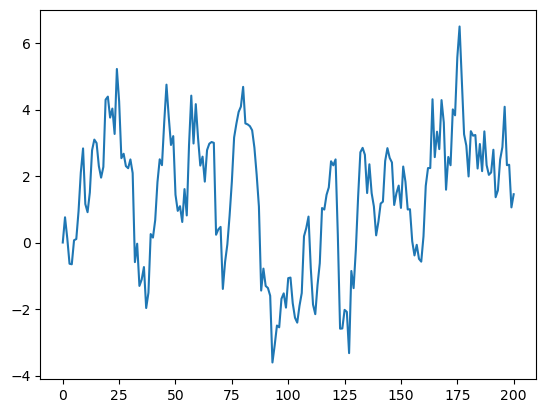

In [22]:
α = 0.9
T = 200
x = np.empty(T+1)
x[0] = 0
rng = np.random.default_rng()

for t in range(T):
    x[t+1] = α * x[t] + rng.standard_normal()

plt.plot(x)
plt.show()

```{solution-end}
```


```{exercise-start}
:label: pbe_ex2

Exercise 1-ന്റെ നിങ്ങളുടെ solution-ൽ നിന്ന് തുടങ്ങി, $\alpha=0$, $\alpha=0.8$, $\alpha=0.98$ എന്ന മൂന്ന് cases-നും ഓരോ simulated time series plot ചെയ്യുക.

$\alpha$ values ഒന്നൊന്നായി തിരഞ്ഞെടുക്കാൻ ഒരു `for` loop ഉപയോഗിക്കുക.

കഴിയുമെങ്കിൽ, മൂന്ന് time series-നെയും വേർതിരിച്ച് കാണിക്കാൻ ഒരു legend കൂടി add ചെയ്യുക.

```{hint}
:class: dropdown

* `show()` call ചെയ്യുന്നതിന് മുൻപ് `plot()` function പലതവണ call ചെയ്താൽ, നിങ്ങൾ produce ചെയ്യുന്ന lines എല്ലാം ഒരേ figure-ൽ വരും.
* Legend-നായി, `var = 42` എന്ന് കരുതുക. അങ്ങനെയെങ്കിൽ `f'foo{var}'` എന്ന expression-ന്റെ result `'foo42'` ആയിരിക്കും.
```

```{exercise-end}
```


```{solution-start} pbe_ex2
:class: dropdown
```

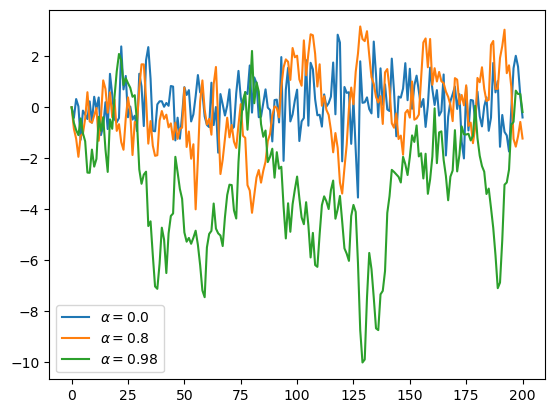

In [23]:
α_values = [0.0, 0.8, 0.98]
T = 200
x = np.empty(T+1)
rng = np.random.default_rng()

for α in α_values:
    x[0] = 0
    for t in range(T):
        x[t+1] = α * x[t] + rng.standard_normal()
    plt.plot(x, label=f'$\\alpha = {α}$')

plt.legend()
plt.show()

```{note}
Solution-ലെ `f'$\\alpha = {α}$'` എന്നത് [f-String](https://docs.python.org/3/tutorial/inputoutput.html#tut-f-strings)-ന്റെ ഒരു application ആണ്. ഒരു expression-നെ `{}`-ക്കുള്ളിൽ എഴുതാൻ f-string അനുവദിക്കുന്നു.

അങ്ങനെ `{}`-ക്കുള്ളിൽ എഴുതിയിരിക്കുന്ന expression Python evaluate ചെയ്യും. ലഭിക്കുന്ന result string-ലേക്ക് ചേർക്കപ്പെടും.
```

```{solution-end}
```

```{exercise-start}
:label: pbe_ex3

മുൻപത്തെ exercises പോലെ, താഴെ കൊടുത്തിരിക്കുന്ന time series-ഉം plot ചെയ്യുക:

$$
x_{t+1} = \alpha \, |x_t| + \epsilon_{t+1}
\quad \text{where} \quad
x_0 = 0
\quad \text{and} \quad t = 0,\ldots,T
$$

Use $T=200$, $\alpha = 0.9$ and $\{\epsilon_t\}$ as before.

$|x_t|$ എന്ന absolute value compute ചെയ്യാൻ ഉപയോഗിക്കാവുന്ന ഒരു function online-ൽ search ചെയ്യുക.
```

```{exercise-end}
```


```{solution-start} pbe_ex3
:class: dropdown
```

Here's one solution:

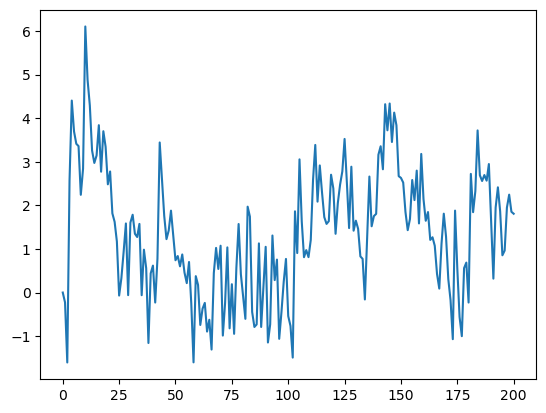

In [24]:
α = 0.9
T = 200
x = np.empty(T+1)
x[0] = 0
rng = np.random.default_rng()

for t in range(T):
    x[t+1] = α * np.abs(x[t]) + rng.standard_normal()

plt.plot(x)
plt.show()

```{solution-end}
```


```{exercise-start}
:label: pbe_ex4
```

മിക്കവാറും എല്ലാ programming languages-ന്റെയും ഒരു പ്രധാന aspect എന്നുപറയുന്നത് branching-ഉം
conditions-ഉം ആണ്.

Python-ൽ, conditions സാധാരണയായി if--else syntax ഉപയോഗിച്ചാണ് implement ചെയ്യുന്നത്.

താഴെക്കൊടുത്തിരിക്കുന്ന example-ൽ, ഒരു array-യിലെ ഓരോ negative number-നും -1-ഉം, ഓരോ nonnegative number-നും 1-ഉം print ചെയ്യുന്നു.

In [25]:
numbers = [-9, 2.3, -11, 0]

In [26]:
for x in numbers:
    if x < 0:
        print(-1)
    else:
        print(1)

-1
1
-1
1


ഇനി, absolute value compute ചെയ്യാൻ ഒരു existing function ഉപയോഗിക്കാതെ Exercise 3-ന് ഒരു പുതിയ solution എഴുതുക.

ആ existing function-ന് പകരം ഒരു if--else condition ഉപയോഗിക്കുക.

```{exercise-end}
```

```{solution-start} pbe_ex4
:class: dropdown
```

Here's one way:

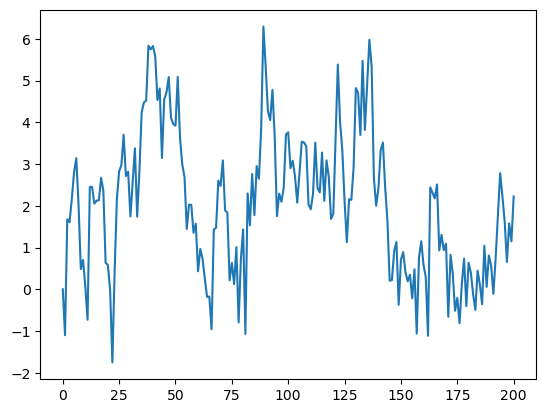

In [27]:
α = 0.9
T = 200
x = np.empty(T+1)
x[0] = 0
rng = np.random.default_rng()

for t in range(T):
    if x[t] < 0:
        abs_x = - x[t]
    else:
        abs_x = x[t]
    x[t+1] = α * abs_x + rng.standard_normal()

plt.plot(x)
plt.show()

short ആയിട്ടുള്ള ഒരു solution താഴെ കാണാം:

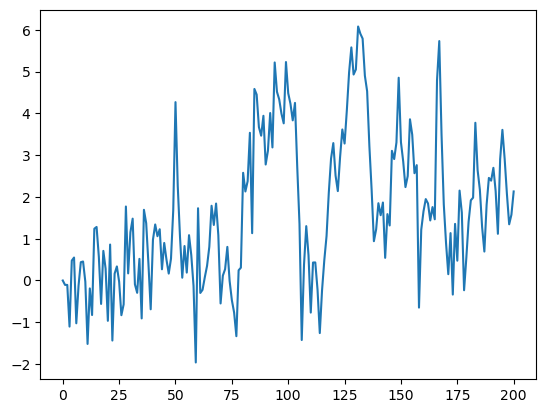

In [28]:
α = 0.9
T = 200
x = np.empty(T+1)
x[0] = 0
rng = np.random.default_rng()

for t in range(T):
    abs_x = - x[t] if x[t] < 0 else x[t]
    x[t+1] = α * abs_x + rng.standard_normal()

plt.plot(x)
plt.show()

```{solution-end}
```



```{exercise-start}
:label: pbe_ex5
```

ഇനി കുറച്ച് thought-ഉം planning-ഉം ആവശ്യമുള്ള ഒരു harder exercise ചെയ്യാം.

[Monte Carlo](https://en.wikipedia.org/wiki/Monte_Carlo_method) ഉപയോഗിച്ച് $\pi$-യുടെ ഒരു approximation compute ചെയ്യുക എന്നതാണ് task.

താഴെ കൊടുത്തിരിക്കുന്ന import statement മാത്രം ഉപയോഗിക്കുക:

In [29]:
import numpy as np

```{hint}
:class: dropdown

Your hints are as follows:

* If $U$ is a bivariate uniform random variable on the unit square $(0, 1)^2$, then the probability that $U$ lies in a subset $B$ of $(0,1)^2$ is equal to the area of $B$.
* If $U_1,\ldots,U_n$ are IID copies of $U$, then, as $n$ gets large, the fraction that falls in $B$, converges to the probability of landing in $B$.
* For a circle, $area = \pi * radius^2$.
```

```{exercise-end}
```


```{solution-start} pbe_ex5
:class: dropdown
```

Consider the circle of diameter 1 embedded in the unit square.

Let $A$ be its area and let $r=1/2$ be its radius.

If we know $\pi$ then we can compute $A$ via
$A = \pi r^2$.

But here the point is to compute $\pi$, which we can do by
$\pi = A / r^2$.

Summary: If we can estimate the area of a circle with diameter 1, then dividing
by $r^2 = (1/2)^2 = 1/4$ gives an estimate of $\pi$.

We estimate the area by sampling bivariate uniforms and looking at the
fraction that falls into the circle.

In [30]:
n = 1000000 # sample size for Monte Carlo simulation
rng = np.random.default_rng()

count = 0
for i in range(n):

    # drawing random positions on the square
    u, v = rng.uniform(), rng.uniform()

    # check whether the point falls within the boundary
    # of the unit circle centred at (0.5,0.5)
    d = np.sqrt((u - 0.5)**2 + (v - 0.5)**2)

    # if it falls within the inscribed circle, 
    # add it to the count
    if d < 0.5:
        count += 1

area_estimate = count / n

print(area_estimate * 4)  # dividing by radius**2

3.143584


```{solution-end}
```